In [18]:
## page 40 예제 
import warnings ;warnings.filterwarnings('ignore')
import sys ;sys.path.append("../../")
from  CommonFunc_04 import *
DataPreprocessing.plotSetting(setting_info=True)
import tensorflow as tf
print(yellow(f"tensorflow version : {tf.__version__}"))
import tensorflow as tf, numpy as np
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import keras

  ⁍ 현재 경로의 폴더 목록 --
  폴더1 :  /Users/forrestdpark/Desktop/PDG/DailyHelloWorld_/개발자를위한머신러닝/__pycache__
  폴더2 :  /Users/forrestdpark/Desktop/PDG/DailyHelloWorld_/개발자를위한머신러닝/model
  폴더3 :  /Users/forrestdpark/Desktop/PDG/DailyHelloWorld_/개발자를위한머신러닝/Data
../ +  ../../ 경로 python path 에 추가. 
◎ 주피터 가상환경  : base
◎ Python 설치 경로:/opt/anaconda3/bin/python
◎ Graph 한글화 Setting
패키지 목록이 package_list.txt 파일에 저장되었습니다.
  - ◎ matplot graph set complete
tensorflow version : 2.16.1


---
###  가위바위보인식

In [ ]:
# !wget --no-check-certificate \
#     https://storage.googleapis.com/learning-datasets/rps.zip \
#     -O ./Data/rps.zip

In [ ]:
# !wget --no-check-certificate \
#     https://storage.googleapis.com/learning-datasets/rps-test-set.zip \
#     -O ./Data/rps-test-set.zip

In [31]:
def zip_extarction(source_path,target_folder_path):
    import zipfile
    zip_ref = zipfile.ZipFile(source_path,'r')
    zip_ref.extractall(target_folder_path)
    zip_ref.close()

# zip_extarction('./Data/rps.zip',"./Data")
# zip_extarction('./Data/rps-test-set.zip',"./Data")


def train_val_generator():
    print("\n◎Augumented training generator -- update(2024.10.16) by pdg")
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
    TRANING_DIR = './Data/rps/'
    
    ## data augumentation 을 위한 IDG  생성 
    training_datagen = ImageDataGenerator(
        rescale =1./255,
        rotation_range =40,
        width_shift_range =0.2,
        height_shift_range =0.2,
        shear_range = 0.2,
        horizontal_flip = True,
        fill_mode = 'nearest'
    )
    ## train data 를 dict 에서 가져와서 class 분류 한 tg
    train_generator = training_datagen.flow_from_directory(
        TRANING_DIR,
        target_size = (150,150),
        class_mode = 'categorical'
    )
    
    VALIDATION_DIR = "./Data/rps-test-set/"
    validation_datagen = ImageDataGenerator(rescale = 1./255)
    validation_generator = validation_datagen.flow_from_directory(
        VALIDATION_DIR,
        target_size=(150,150),
        class_mode='categorical'
    )   
    
    
    return train_generator,validation_generator
train_generator,validation_generator=train_val_generator()

def rock_cisor_paper_model(
        conv2F_n = 64,
        conv2F_size =(3,3),
        in_shape =(150,150,3),
        max_pooling_filter_size =(2,2),
        h_layer_act_func= 'relu',
        o_layer_act_func = 'softmax',
        neuron_units = 512,
        class_num =3
    ):
    print("\n◎가위바위보 이미지 분류 모델 생성 -- update(2024.10.16) by pdg")
    print(f"""\t parameter info: 
                - 기본 합성곱층 필터 개수: {conv2F_n} 
                - 기본 합성곱층 필터 사이즈 :{conv2F_size} 
                - 데이터 input 형태 : {in_shape} 
                - 맥스 풀링 필터 사이즈 :{max_pooling_filter_size} 
                - 은닉층 활성화 함수 {h_layer_act_func} 
                - 출력층 활성화 함수 {o_layer_act_func} 
                - 출력전 학습 뉴런 수 : {neuron_units}
                - 클래스 종류 수 : {class_num}
                """)
    import tensorflow as tf
    model = tf.keras.models.Sequential([
        ## 입력크기는 원하는 이미지 와 일치 ( 150,150,3)
        tf.keras.layers.Conv2D(conv2F_n,conv2F_size,activation = h_layer_act_func, input_shape = in_shape), 
        tf.keras.layers.MaxPooling2D(max_pooling_filter_size),
        
        ## 두번째 합성곱층 
        tf.keras.layers.Conv2D(conv2F_n,conv2F_size, activation = h_layer_act_func),
        tf.keras.layers.MaxPooling2D(max_pooling_filter_size),
        ## 세번째 합성곱층 
        tf.keras.layers.Conv2D(conv2F_n*2,conv2F_size, activation = h_layer_act_func),
        tf.keras.layers.MaxPooling2D(max_pooling_filter_size),
        ## 네번째 합성곱층 
        tf.keras.layers.Conv2D(conv2F_n*2,conv2F_size, activation = h_layer_act_func),
        tf.keras.layers.MaxPooling2D(max_pooling_filter_size),
        
        ## 밀집층 전달을 위한 신경펼침
        tf.keras.layers.Flatten(),
        # 512 뉴런을 가진 은닉층 
        tf.keras.layers.Dense(neuron_units, activation='relu'),
        tf.keras.layers.Dense(class_num,activation =o_layer_act_func) ## 가위바위보
        
    ])
    print("\t model compile....")
    if class_num > 2:
        print("범주형 카테고리")
        model.compile(loss= 'categorical_crossentropy',
                        optimizer = 'rmsprop',
                        metrics =['accuracy']
                        
                    )
        
    
    return model 

model = rock_cisor_paper_model()
model.summary()
test_epochs =4
model.fit(train_generator,
          epochs =test_epochs,
          validation_data =validation_generator)






◎Augumented training generator -- update(2024.10.16) by pdg
Found 2520 images belonging to 3 classes.
Found 372 images belonging to 3 classes.

◎가위바위보 이미지 분류 모델 생성 -- update(2024.10.16) by pdg
	 parameter info: 
                - 기본 합성곱층 필터 개수: 64 
                - 기본 합성곱층 필터 사이즈 :(3, 3) 
                - 데이터 input 형태 : (150, 150, 3) 
                - 맥스 풀링 필터 사이즈 :(2, 2) 
                - 은닉층 활성화 함수 relu 
                - 출력층 활성화 함수 softmax 
                - 출력전 학습 뉴런 수 : 512
                - 클래스 종류 수 : 3
                
	 model compile....
범주형 카테고리


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_67 (Conv2D)              │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_65 (MaxPooling2D) │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_68 (Conv2D)              │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_66 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_67 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_68 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,473,475 (13.25 MB)

 Trainable params: 3,473,475 (13.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
79/79 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.3347 - loss: 1.4287 - val_accuracy: 0.6290 - val_loss: 1.0476
Epoch 2/4
79/79 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.4449 - loss: 1.0350 - val_accuracy: 0.5565 - val_loss: 0.8278
Epoch 3/4
79/79 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.7159 - loss: 0.6359 - val_accuracy: 0.7903 - val_loss: 0.3486
Epoch 4/4
79/79 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.8542 - loss: 0.3636 - val_accuracy: 0.7500 - val_loss: 0.6622


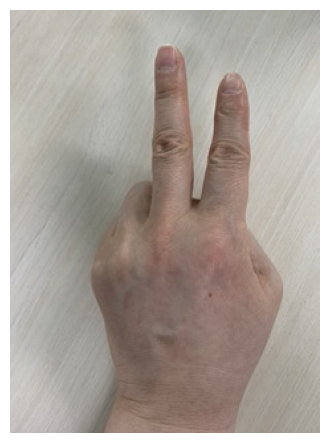

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
./images/rps_test/rsp_image_1.jpg는 가위입니다


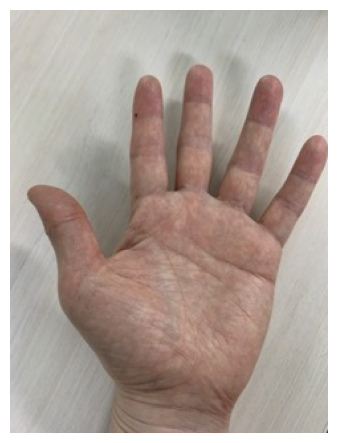

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
./images/rps_test/rsp_image_2.jpg는 보입니다


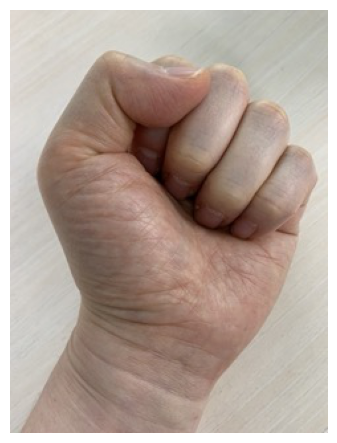

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
./images/rps_test/rsp_image_3.jpg는 보입니다


In [36]:
def rsp_image_test(img_size=(150,150)):
    sample_images =[ './images/rps_test/rsp_image_{}.jpg'.format(i) for i in range(1,4)]
    rsp_name = ['보','바위','가위']

    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.image as mpimg
    from keras.preprocessing import image

    for fn in sample_images:
        ## image print
        plt.imshow(mpimg.imread(fn))
        plt.axis('off')
        plt.show()
        
        ## image load
        img = tf.keras.utils.load_img(fn,target_size=img_size)
        x = tf.keras.utils.img_to_array(img)
        x = np.expand_dims(x,axis=0)
        
        classes = model.predict(x)
        idx  = np.argmax(classes[0])
        print(f'{fn}는 {rsp_name[idx]}입니다')
rsp_image_test()

---
## 3.9 drop out 규제
- dropout regularization
- 특정 신경망에 영향을 받아 과도하게 전문화 되는 경우를 규제함. 


In [49]:
def overfitting_test(
    trainig_score= 0.94,
    validation_score = 0.88
    ):
    if trainig_score> validation_score:
        print(yellow(" 훈련이 검증보다 잘되니 과대 적합입니다."))
    else:
         print(yellow(" 검증이 훈련보다 잘되니 과소 적합입니다."))

def drop_out_test(test_epoch=2):
    callbacks = callback_setting(percent=0.85)
    mnist = tf.keras.datasets.fashion_mnist

    (training_images,training_labels),(test_images,test_labels)\
    =mnist.load_data()
        
    ## 이미지 reshape ,정규화 
    training_images =training_images.reshape(60000,28,28,1)
    training_images= training_images/255.0
    test_images = test_images.reshape(10000,28,28,1)
    test_images = test_images/255.0

    model_01  = tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape = (28,28)),
        tf.keras.layers.Dense(256,activation= tf.nn.relu),
        tf.keras.layers.Dense(128,activation= tf.nn.relu),
        tf.keras.layers.Dense(64,activation= tf.nn.relu),
        tf.keras.layers.Dense(10,activation= tf.nn.softmax)
        
    ])
    
    model_02 = tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape = (28,28)),
        tf.keras.layers.Dense(256,activation= tf.nn.relu),
            tf.keras.layers.Dropout(0.2), ## 20% random drop
        tf.keras.layers.Dense(128,activation= tf.nn.relu),
            tf.keras.layers.Dropout(0.2), ## 20% random drop
        tf.keras.layers.Dense(64,activation= tf.nn.relu),
            tf.keras.layers.Dropout(0.2), ## 20% random drop
        tf.keras.layers.Dense(10,activation= tf.nn.softmax)
        
    ])
    model = model_02
    model.compile(optimizer='adam',
            loss = 'sparse_categorical_crossentropy',
            metrics= ['accuracy']
            )
    
    history = model.fit(training_images, training_labels, epochs=test_epoch, callbacks=[callbacks], validation_data=(test_images, test_labels))

    # 훈련 및 검증 정확도 출력
    training_accuracy = history.history['accuracy'][-1]  # 마지막 epoch의 훈련 정확도
    validation_accuracy = history.history['val_accuracy'][-1]  # 마지막 epoch의 검증 정확도
    # evaluate_model(model,test_data=test_images,test_label=test_labels)
    overfitting_test(training_accuracy,validation_accuracy)

drop_out_test()


Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7313 - loss: 0.7506 - val_accuracy: 0.8384 - val_loss: 0.4399
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8427 - loss: 0.4402 - val_accuracy: 0.8530 - val_loss: 0.4025
 검증이 훈련보다 잘되니 과소 적합입니다.
